<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap13/13_3_Neighborhood_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 13.3: Neighborhood sampling**

This notebook investigates neighborhood sampling of graphs as in figure 13.10 from the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TO DO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

Let's construct the graph from figure 13.10, which has 23 nodes.

In [5]:
# Define adjacency matrix
A = np.array([[0,1,1,1,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0],
              [1,0,1,0,0, 0,0,0,1,1, 0,0,0,0,0, 0,0,0,0,0, 0,0,0],
              [1,1,0,1,0, 0,0,0,0,1, 0,0,0,0,0, 0,0,0,0,0, 0,0,0],
              [1,0,1,0,1, 0,1,1,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0],
              [0,0,0,1,0, 1,0,1,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0],
              [0,0,0,0,1, 0,0,1,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0],
              [0,0,0,1,0, 0,0,1,0,1, 1,0,0,0,0, 0,0,0,0,0, 0,0,0],
              [0,0,0,1,1, 1,1,0,0,0, 1,0,0,1,0, 0,0,0,0,0, 0,0,0],
              [0,1,0,0,0, 0,0,0,0,1, 0,0,0,0,0, 0,0,0,0,0, 0,0,0],
              [0,1,1,0,0, 0,1,0,1,0, 0,1,1,0,0, 0,1,0,0,0, 0,0,0],
              [0,0,0,0,0, 0,1,1,0,0, 0,0,1,0,0, 0,0,0,0,0, 0,0,0],
              [0,0,0,0,0, 0,0,0,0,1, 0,0,0,0,1, 1,1,0,0,0, 0,0,0],
              [0,0,0,0,0, 0,0,0,0,1, 1,0,0,1,0, 0,1,1,0,0, 0,0,0],
              [0,0,0,0,0, 0,0,1,0,0, 0,0,1,0,0, 0,0,1,1,0, 0,0,0],
              [0,0,0,0,0, 0,0,0,0,0, 0,1,0,0,0, 1,0,0,0,1, 0,0,0],
              [0,0,0,0,0, 0,0,0,0,0, 0,1,0,0,1, 0,1,0,0,1, 0,0,0],
              [0,0,0,0,0, 0,0,0,0,1, 0,1,1,0,0, 1,0,1,0,1, 0,0,0],
              [0,0,0,0,0, 0,0,0,0,0, 0,0,1,1,0, 0,1,0,1,0, 1,1,1],
              [0,0,0,0,0, 0,0,0,0,0, 0,0,0,1,0, 0,0,1,0,0, 0,0,1],
              [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,1, 1,1,0,0,0, 1,0,0],
              [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,1,0,1, 0,1,0],
              [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,1,0,0, 1,0,1],
              [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,1,1,0, 0,1,0]]);
print(A)

[[0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 

In [6]:
# Routine to draw graph structure, highlighting original node (brown in fig 13.10)
# and neighborhood nodes (orange in figure 13.10)
def draw_graph_structure(adjacency_matrix, original_node, neighborhood_nodes=None):

  G = nx.Graph()
  n_node = adjacency_matrix.shape[0]
  for i in range(n_node):
    for j in range(i):
      if adjacency_matrix[i,j]:
          G.add_edge(i,j)

  color_map = []

  for node in G:
    if original_node[node]:
      color_map.append('brown')
    else:
      if neighborhood_nodes[node]:
        color_map.append('orange')
      else:
        color_map.append('white')

  nx.draw(G, nx.spring_layout(G, seed = 7), with_labels=True,node_color=color_map)
  plt.show()

Output layer:


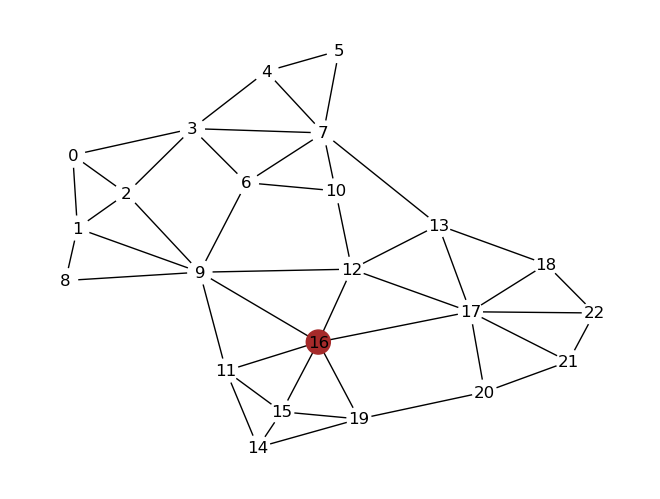

In [7]:
n_nodes = A.shape[0]

# Define a single output layer node
output_layer_nodes=np.zeros((n_nodes,1)); output_layer_nodes[16]=1
# Define the neighboring nodes to draw (none)
neighbor_nodes = np.zeros((n_nodes,1))
print("Output layer:")
draw_graph_structure(A, output_layer_nodes, neighbor_nodes)

Let's imagine that we want to form a batch for a node labelling task that consists of just node 16 in the output layer (highlighted).   The network consists of the input, hidden layer 1, hidden layer2, and the output layer.

[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]]
Hidden layer 2:


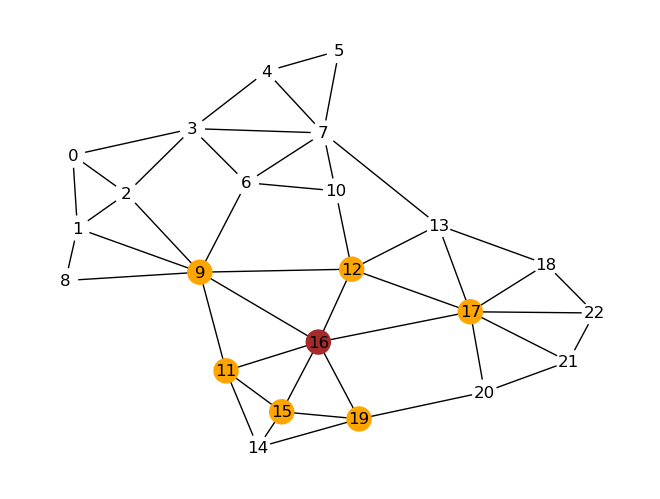

In [9]:
# TODO Find the nodes in hidden layer 2 that connect to node 16 in the output layer
# using the adjacency matrix
# Replace this line:
hidden_layer2_nodes = np.zeros((n_nodes,1));

# TODO: 找到隐藏层 2 中连接到输出层节点 16 的节点
# 使用邻接矩阵 A 找到连接到节点 16 的隐藏层 2 节点
hidden_layer2_indices = np.where(A[:, 16] != 0)[0]  # 找到连接到节点 16 的节点索引
hidden_layer2_nodes[hidden_layer2_indices] = 1  # 将这些节点标记为 1

# 打印隐藏层 2 中连接到节点 16 的节点
print(hidden_layer2_nodes)
print("Hidden layer 2:")
draw_graph_structure(A, output_layer_nodes, hidden_layer2_nodes)

Hidden layer 1:
[[0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


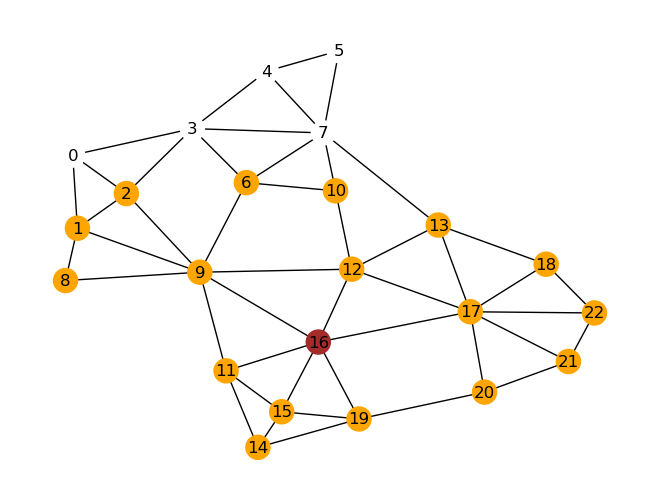

In [10]:
# TODO - Find the nodes in hidden layer 1 that connect that connect to node 16 in the output layer
# using the adjacency matrix
# Replace this line:
hidden_layer1_nodes = np.zeros((n_nodes,1));

# 第二步：找到隐藏层 1 中连接到隐藏层 2 的这些节点的节点
hidden_layer1_nodes = np.zeros((n_nodes, 1))
for node in hidden_layer2_indices:
    hidden_layer1_indices = np.where(A[:, node] != 0)[0]  # 找到隐藏层 1 中连接到当前隐藏层 2 节点的节点
    hidden_layer1_nodes[hidden_layer1_indices] = 1  # 将这些节点标记为 1
    
print("Hidden layer 1:")
print(hidden_layer1_nodes)
draw_graph_structure(A, output_layer_nodes, hidden_layer1_nodes)

Input layer:


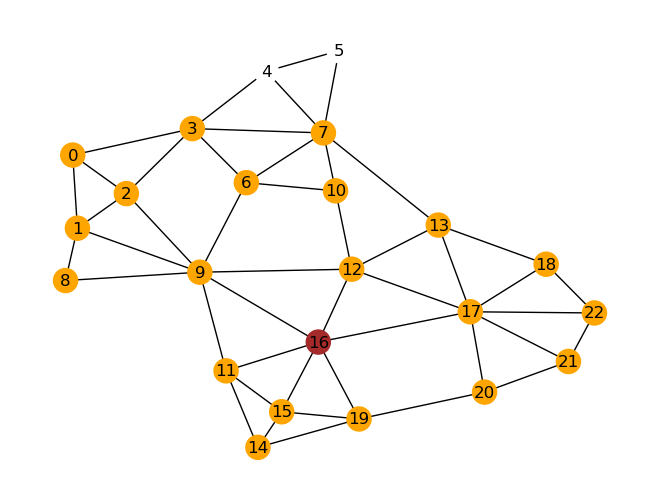

In [11]:
# TODO Find the nodes in the input layer that connect to node 16 in the output layer
# using the adjacency matrix
# Replace this line:
input_layer_nodes = np.zeros((n_nodes,1));

# 第三步：找到输入层中连接到隐藏层 1 的这些节点的节点
input_layer_nodes = np.zeros((n_nodes, 1))
for node in np.where(hidden_layer1_nodes != 0)[0]:
    input_layer_indices = np.where(A[:, node] != 0)[0]  # 找到输入层中连接到当前隐藏层 1 节点的节点
    input_layer_nodes[input_layer_indices] = 1  # 将这些节点标记为 1
    
print("Input layer:")
draw_graph_structure(A, output_layer_nodes, input_layer_nodes)

This is bad news.  This is a fairly sparsely connected graph (i.e. adjacency matrix is mostly zeros) and there are only two hidden layers.  Nonetheless, we have to involve almost all the nodes in the graph to compute the loss at this output.

To resolve this problem, we'll use neighborhood sampling.  We'll start again with a single node in the output layer.

Output layer:


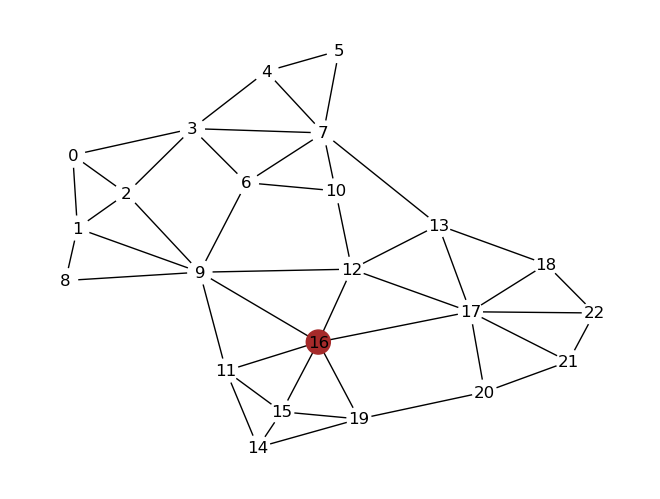

In [13]:
print("Output layer:")
draw_graph_structure(A, output_layer_nodes, neighbor_nodes)

In [14]:
# Define umber of neighbors to sample
n_sample = 3

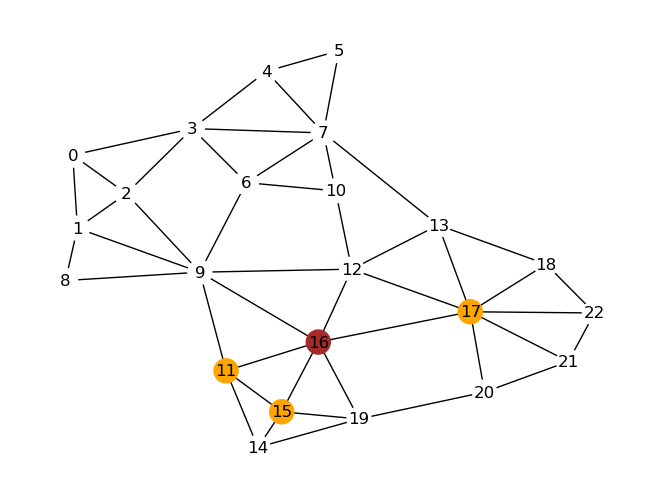

In [15]:
# TODO Find the nodes in hidden layer 2 that connect to node 16 in the output layer
# using the adjacency matrix.  Then sample n_sample of these nodes randomly without
# replacement.

# Replace this line:
hidden_layer2_nodes = np.zeros((n_nodes,1));

# TODO: 找到隐藏层 2 中连接到输出层节点 16 的节点
# 使用邻接矩阵 A 找到连接到节点 16 的隐藏层 2 节点
hidden_layer2_indices = np.where(A[:, 16] != 0)[0]  # 找到连接到节点 16 的节点索引

# Sample n_sample nodes randomly without replacement
sampled_nodes = np.random.choice(hidden_layer2_indices, size=n_sample, replace=False)

# Replace the line with the sampled nodes
hidden_layer2_nodes = np.zeros((n_nodes, 1))
hidden_layer2_nodes[sampled_nodes] = 1  # Mark the sampled nodes

draw_graph_structure(A, output_layer_nodes, hidden_layer2_nodes)

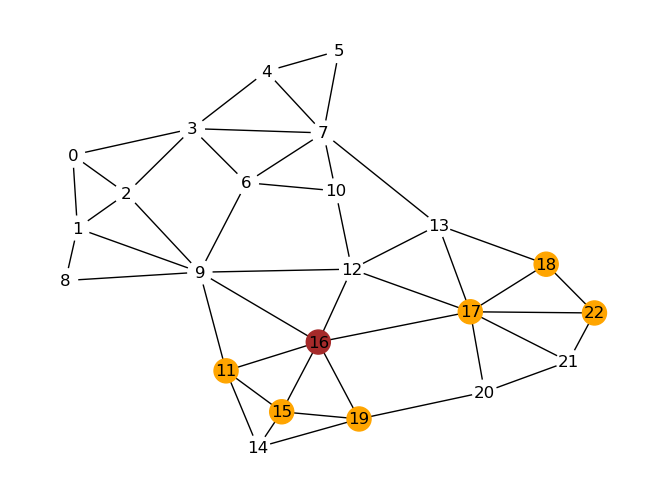

In [16]:
# TODO Find the nodes in hidden layer 1 that connect to the nodes in hidden layer 2
# using the adjacency matrix.  Then sample n_sample of these nodes randomly without
# replacement.  Make sure not to sample nodes that were already included in hidden layer 2 our the output layer.
# The nodes at hidden layer 1 are the union of these nodes and the nodes in hidden layer 2

# Replace this line:
hidden_layer1_nodes = np.zeros((n_nodes,1));

# Find the nodes in hidden layer 1 that connect to the nodes in hidden layer 2
hidden_layer2_indices = np.where(hidden_layer2_nodes == 1)[0]  # Indices of hidden layer 2 nodes
hidden_layer1_candidates = np.where(np.any(A[:, hidden_layer2_indices], axis=1))[0]  # Nodes in hidden layer 1 connected to hidden layer 2

# Exclude nodes already in hidden layer 2 or the output layer
excluded_nodes = np.where((hidden_layer2_nodes == 1) | (output_layer_nodes == 1))[0]
hidden_layer1_candidates = np.setdiff1d(hidden_layer1_candidates, excluded_nodes)

# Sample n_sample nodes randomly without replacement
sampled_nodes = np.random.choice(hidden_layer1_candidates, size=n_sample, replace=False)

# Combine the sampled nodes with the nodes in hidden layer 2
hidden_layer1_nodes = np.zeros((n_nodes, 1))
hidden_layer1_nodes[sampled_nodes] = 1  # Mark the sampled nodes
hidden_layer1_nodes[hidden_layer2_indices] = 1  # Include hidden layer 2 nodes

draw_graph_structure(A, output_layer_nodes, hidden_layer1_nodes)


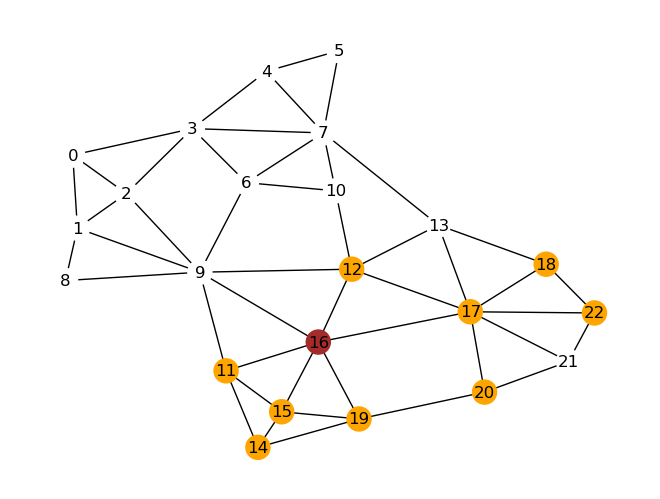

In [17]:
# TODO Find the nodes in the input layer that connect to the nodes in hidden layer 1
# using the adjacency matrix.  Then sample n_sample of these nodes randomly without
# replacement.  Make sure not to sample nodes that were already included in hidden layer 1,2, or the output layer.
# The nodes at the input layer are the union of these nodes and the nodes in hidden layers 1 and 2

# Replace this line:
input_layer_nodes = np.zeros((n_nodes,1));

# Find the nodes in the input layer that connect to the nodes in hidden layer 1
hidden_layer1_indices = np.where(hidden_layer1_nodes == 1)[0]  # Indices of hidden layer 1 nodes
input_layer_candidates = np.where(np.any(A[:, hidden_layer1_indices], axis=1))[0]  # Nodes in input layer connected to hidden layer 1

# Exclude nodes already in hidden layer 1, hidden layer 2, or the output layer
excluded_nodes = np.where((hidden_layer1_nodes == 1) | (hidden_layer2_nodes == 1) | (output_layer_nodes == 1))[0]
input_layer_candidates = np.setdiff1d(input_layer_candidates, excluded_nodes)

# Sample n_sample nodes randomly without replacement
sampled_nodes = np.random.choice(input_layer_candidates, size=n_sample, replace=False)

# Combine the sampled nodes with the nodes in hidden layers 1 and 2
input_layer_nodes = np.zeros((n_nodes, 1))
input_layer_nodes[sampled_nodes] = 1  # Mark the sampled nodes
input_layer_nodes[hidden_layer1_indices] = 1  # Include hidden layer 1 nodes
input_layer_nodes[np.where(hidden_layer2_nodes == 1)[0]] = 1  # Include hidden layer 2 nodes

draw_graph_structure(A, output_layer_nodes, input_layer_nodes)

If you did this correctly, there should be 9 yellow nodes in the figure.  The "receptive field" of node 16 in the output layer increases much more slowly as we move back through the layers of the network.